# Classification Metrics

A comprehensive guide to evaluating how well classification models perform — beyond simple accuracy.

---

## Table of Contents

1. [Setup & Data Preparation](#setup)
2. [Accuracy](#accuracy)
3. [Confusion Matrix](#confusion-matrix)
4. [Precision](#precision)
5. [Recall](#recall)
6. [F1-Score](#f1-score)
7. [Multi-class Metrics & the `average` Parameter](#multi-class)
8. [Classification Report](#classification-report)
9. [Summary — Which Metric to Use?](#summary)

---
## 1. Setup & Data Preparation

**Dataset:** UCI Heart Disease — predict severity of heart disease (`num`: 0 = no disease, 1–4 = disease severity).

**Preprocessing steps:**
- Drop non-predictive columns (`id`, `dataset`)
- Impute missing values: median for numeric, mode for categorical
- One-hot encode categorical features
- Scale features with `StandardScaler` (required for Logistic Regression convergence)
- Train two models for comparison: **Logistic Regression** and **Decision Tree**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../../datasets/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# Drop non-predictive columns
df = df.drop(columns=["id", "dataset"], errors="ignore")

# Fill missing values: median for numeric, mode for categorical features
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

df.head()

C:\Users\RITESH\AppData\Local\Temp\ipykernel_25684\4131128899.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)
C:\Users\RITESH\AppData\Local\Temp\ipykernel_25684\4131128899.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train , x_test , y_train , y_test = train_test_split(df.drop("num",axis=1) , df["num"] , test_size=0.2 , random_state=42)

x_train.shape , x_test.shape , y_train.shape , y_test.shape

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [6]:
from sklearn.linear_model import LogisticRegression     # despite the name, it is a classification model
from sklearn.tree import DecisionTreeClassifier

In [7]:
classifier1 = LogisticRegression(max_iter=1000)
classifier2 = DecisionTreeClassifier()

In [8]:
classifier1.fit(x_train , y_train )
classifier2.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [9]:
y_pred1 = classifier1.predict(x_test)
y_pred2 = classifier2.predict(x_test)

## 2. Accuracy

Accuracy measures the proportion of correct predictions out of all predictions made.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

| Symbol | Meaning |
|--------|---------|
| TP | True Positives — correctly predicted positive |
| TN | True Negatives — correctly predicted negative |
| FP | False Positives — predicted positive, actually negative *(Type I Error)* |
| FN | False Negatives — predicted negative, actually positive *(Type II Error)* |

### The Accuracy Trap — A Real-World Example

Imagine an airport security model trained to detect terrorists among passengers:

| | Value |
|--|--|
| Total passengers | 1,00,000 |
| Terrorists | 1 |
| Non-terrorists | 99,999 |

A model that **always predicts "Not a Terrorist"** would get:

$$
\text{Accuracy} = \frac{0 + 99999}{1,00,000} = 99.999\%
$$

Looks great on paper — but it **missed the only actual terrorist (FN = 1, Type II Error)**. This is a catastrophic failure that accuracy completely hides.

### Type I vs Type II Errors

| | Type I Error (FP) | Type II Error (FN) |
|--|--|--|
| **What happened** | Predicted Positive, was actually Negative | Predicted Negative, was actually Positive |
| **Also known as** | False Alarm | Miss |
| **Airport example** | Flagging an innocent passenger as terrorist | Missing an actual terrorist |
| **Medical example** | Healthy patient diagnosed with disease | Sick patient told they are healthy |

> In most high-stakes scenarios, **Type II errors (FN) are more dangerous** — missing a real threat is worse than a false alarm.

### Limitations

- **Misleading on imbalanced data** — majority-class prediction inflates accuracy while the minority class is entirely ignored.
- **Hides error types** — doesn't distinguish between Type I (FP) and Type II (FN) errors, which carry very different real-world costs.

> **Takeaway:** Accuracy is a useful first glance, but always complement it with **Precision**, **Recall**, and **F1-score** — especially on imbalanced datasets.

In [10]:
from sklearn.metrics import accuracy_score , confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.532608695652174
Decision Tree Accuracy: 0.5217391304347826


## 3. Confusion Matrix

A confusion matrix breaks down predictions into four categories, revealing **what kind of errors** a model makes — not just how many.

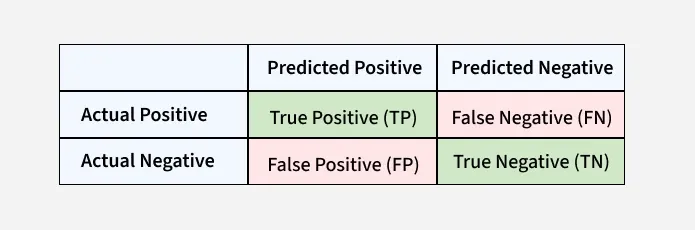

> **Reading the names:** First word = was the prediction **correct**? Second word = what did the model **predict**?
> e.g. *False Positive* → prediction was wrong (**False**), and it predicted **Positive**.

### Multi-class & Imbalanced Data

- For **n classes**, the matrix is **n × n**: entry *(i, j)* = how many times class *i* was predicted as class *j*; diagonal = correct predictions.
- On **imbalanced datasets**, a model predicting only the majority class scores high accuracy, but the matrix exposes it — all minority class samples land in FN, with zero TP.

In [11]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

Logistic Regression Confusion Matrix:
 [[63 12  0  0  0]
 [21 30  0  3  0]
 [ 2 17  2  4  0]
 [ 5 10  6  3  2]
 [ 0  1  1  2  0]]
Decision Tree Confusion Matrix:
 [[58 12  2  3  0]
 [17 23  7  6  1]
 [ 4  6 12  3  0]
 [ 4 12  6  2  2]
 [ 0  1  1  1  1]]


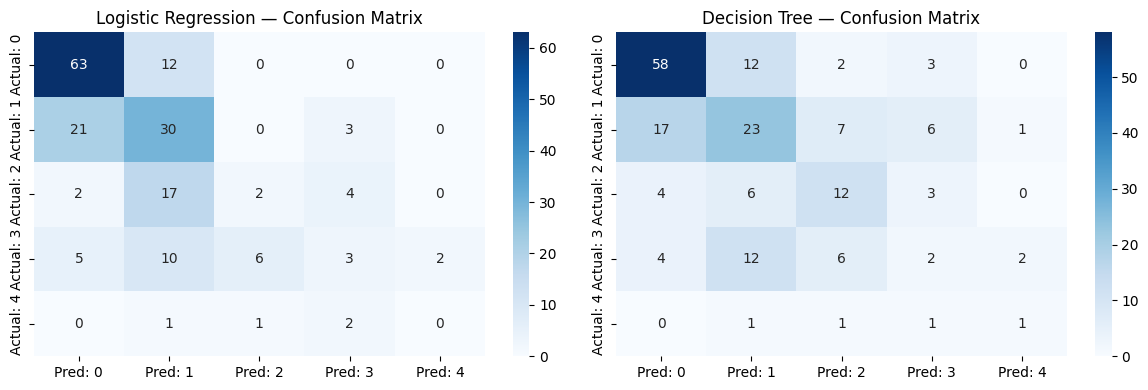

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes, [y_pred1, y_pred2], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, y_pred)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[f"Pred: {c}" for c in classes],
                yticklabels=[f"Actual: {c}" for c in classes])
    ax.set_title(f"{title} — Confusion Matrix")

plt.tight_layout()
plt.show()

## 4. Precision

Precision answers: **"Of all the samples predicted as Positive, how many were actually Positive?"**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

> Precision focuses on **False Positives (FP)** — penalises the model for raising false alarms.

### When to prioritise Precision?

Use Precision when the **cost of a False Positive is high** — incorrectly flagging a negative as positive causes harm.

**Spam Detection Example** *(spam = 1, not spam = 0)*

**Model A:**

| | Predicted: Spam | Predicted: Not Spam |
|---|---|---|
| **Actual: Spam** | 100 (TP) | 170 (FN) |
| **Actual: Not Spam** | **60 (FP)** | 700 (TN) |

$$\text{Precision}_A = \frac{100}{100+60} = 0.625$$

**Model B:**

| | Predicted: Spam | Predicted: Not Spam |
|---|---|---|
| **Actual: Spam** | 100 (TP) | 190 (FN) |
| **Actual: Not Spam** | **10 (FP)** | 700 (TN) |

$$\text{Precision}_B = \frac{100}{100+10} = 0.909$$

Both models have ~80% accuracy, but Model B has far fewer FP (10 vs 60).  
A spam filter that sends legit emails to spam is very annoying — **deploy Model B** since $FP_A > FP_B$.

> **Takeaway:** High Precision → fewer false alarms → fewer legit emails wrongly marked as spam.

## 5. Recall

Recall answers: **"Of all the actual Positives, how many did the model correctly identify?"**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

> Recall focuses on **False Negatives (FN)** — penalises the model for missing real positives.

### When to prioritise Recall?

Use Recall when the **cost of a False Negative is high** — missing an actual positive has serious consequences.

**Cancer Detection Example** *(has cancer = 1, no cancer = 0)*

**Model A:**

| | Predicted: Cancer | Predicted: No Cancer |
|---|---|---|
| **Actual: Cancer** | 1000 (TP) | **200 (FN)** |
| **Actual: No Cancer** | 800 (FP) | 8000 (TN) |

$$\text{Recall}_A = \frac{1000}{1000+200} = 0.833$$

**Model B:**

| | Predicted: Cancer | Predicted: No Cancer |
|---|---|---|
| **Actual: Cancer** | 1000 (TP) | **500 (FN)** |
| **Actual: No Cancer** | 500 (FP) | 8000 (TN) |

$$\text{Recall}_B = \frac{1000}{1000+500} = 0.667$$

Both models have ~90% accuracy, but Model A misses only 200 cancer patients vs 500 in Model B.  
Missing a cancer diagnosis (FN) is life-threatening — **deploy Model A** since $R_A > R_B$.

> **Takeaway:** High Recall → fewer missed positives → fewer cancer cases go undetected.

### Precision vs Recall Trade-off

Improving one often hurts the other:
- **↑ Precision** → model becomes more conservative → flags fewer positives → **↑ FN** → ↓ Recall
- **↑ Recall** → model becomes more aggressive → flags more positives → **↑ FP** → ↓ Precision

This is why we need F1-score to balance both.

## 6. F1-Score

F1-Score is the **harmonic mean** of Precision and Recall — a single metric that balances both.

$$
\text{F1} = \frac{2 \times P \times R}{P + R}
$$

### Why Harmonic Mean, not Arithmetic Mean?

The arithmetic mean $\frac{P+R}{2}$ is too lenient — it gives a decent score even when one value is 0.

**Example:** $P = 0$, $R = 100$

$$
\text{Arithmetic Mean} = \frac{0 + 100}{2} = 50 \quad \text{(misleadingly high!)}
$$

$$
\text{F1} = \frac{2 \times 0 \times 100}{0 + 100} = 0 \quad \text{(correctly penalises!)}
$$

The harmonic mean **pulls F1 toward the smaller value**, so both P and R must be high to achieve a high F1.

### Worked Examples

| Precision | Recall | Arithmetic Mean | F1-Score |
|-----------|--------|-----------------|----------|
| 80 | 80 | 80 | $\frac{2×80×80}{160} = 80$ |
| 60 | 100 | 80 | $\frac{2×60×100}{160} = 75$ |

> Notice: when P=60 and R=100, arithmetic mean = 80 but **F1 = 75** — closer to the smaller value (60). A model can't hide a weak metric behind a strong one.

### When to use F1-Score?

- When **both FP and FN matter** and you need a single balanced number.
- On **imbalanced datasets** where accuracy is misleading.
- When you cannot prioritise Precision over Recall (or vice versa).

In [13]:
from sklearn.metrics import precision_score , recall_score , f1_score

In [14]:
cm = pd.DataFrame(confusion_matrix(y_test, y_pred1), columns=list(range(0,5)))
print("Logistic Regression Confusion Matrix\n", cm)

print("Logistic Regression Precision:", precision_score(y_test, y_pred1 , average="weighted"))
print("Logistic Regression Recall:", recall_score(y_test, y_pred1, average="weighted"))
print("Logistic Regression F1-score:", f1_score(y_test, y_pred1, average="weighted"))

Logistic Regression Confusion Matrix
     0   1  2  3  4
0  63  12  0  0  0
1  21  30  0  3  0
2   2  17  2  4  0
3   5  10  6  3  2
4   0   1  1  2  0
Logistic Regression Precision: 0.4734863566385305
Logistic Regression Recall: 0.532608695652174
Logistic Regression F1-score: 0.489691210488701


### The `average` Parameter — Multi-class Aggregation

In multi-class problems, sklearn computes metrics **per class** then aggregates using the `average` parameter:

| `average` | How it works | Best for |
|-----------|-------------|----------|
| `"macro"` | Simple mean of per-class scores — all classes **equally weighted** | Balanced classes; when minority class matters |
| `"weighted"` | Mean weighted by **actual sample count** per class | Imbalanced data; production performance |
| `"micro"` | Pool all TP/FP/FN globally then compute — each **sample** equally weighted | Severe imbalance |
| `None` | Returns score **per class** as an array | Debugging / per-class inspection |

#### Dog / Cat / Rabbit Example (108 samples)

| | Predicted: Dog | Predicted: Cat | Predicted: Rabbit | Actual Total | **Recall** |
|---|---|---|---|---|---|
| **Actual: Dog** | 25 | 5 | 10 | 40 | 25/40 = **0.62** |
| **Actual: Cat** | 0 | 30 | 4 | 34 | 30/34 = **0.88** |
| **Actual: Rabbit** | 4 | 10 | 20 | 34 | 20/34 = **0.58** |
| **Predicted Total** | 29 | 45 | 34 | 108 | |
| **Precision** | 25/29 = **0.86** | 30/45 = **0.66** | 20/34 = **0.58** | | |

**Macro Precision** = $\frac{0.86 + 0.66 + 0.58}{3} = 0.70$

**Weighted Precision** = $\frac{40}{108}×0.86 + \frac{34}{108}×0.66 + \frac{34}{108}×0.58 = 0.71$

**Per-class F1-Scores:**

$$F1_{Dog} = \frac{2 × 0.86 × 0.62}{0.86 + 0.62} = 0.72, \quad F1_{Cat} = \frac{2 × 0.66 × 0.88}{0.66 + 0.88} = 0.75, \quad F1_{Rabbit} = \frac{2 × 0.58 × 0.58}{0.58 + 0.58} = 0.58$$

**Macro F1** = $\frac{0.72 + 0.75 + 0.58}{3} = 0.68$

**Weighted F1** = $\frac{40}{108}×0.72 + \frac{34}{108}×0.75 + \frac{34}{108}×0.58 = 0.69$

> **Key insight:** F1 per class uses that class's own Precision and Recall — the harmonic mean still pulls toward whichever is smaller.

In [15]:
cm = pd.DataFrame(confusion_matrix(y_test, y_pred2), columns=list(range(0,5)))
print("Decision Tree Confusion Matrix\n", cm)

print("Decision Tree Precision:", precision_score(y_test, y_pred2 , average="weighted"))
print("Decision Tree Recall:", recall_score(y_test, y_pred2, average="weighted"))
print("Decision Tree F1-score:", f1_score(y_test, y_pred2, average="weighted"))

Decision Tree Confusion Matrix
     0   1   2  3  4
0  58  12   2  3  0
1  17  23   7  6  1
2   4   6  12  3  0
3   4  12   6  2  2
4   0   1   1  1  1
Decision Tree Precision: 0.4923401681259198
Decision Tree Recall: 0.5217391304347826
Decision Tree F1-score: 0.5050034305547569


In the output above, the F1-score is closer to the **Precision score** (which is lower) than to the Recall score. This is the harmonic mean property — F1 always pulls toward the **smaller** of the two values, ensuring a model can't mask a weak metric behind a strong one.

### Choosing the Right `average` — Quick Guide

| Scenario | Recommended |
|----------|------------|
| Balanced classes, all equally important | `"macro"` |
| Imbalanced data, reflect real-world distribution | `"weighted"` |
| Severe imbalance, each sample matters equally | `"micro"` |
| Need per-class breakdown (debugging) | `None` |
| Binary classification | `"binary"` (default) |

> When in doubt on imbalanced data: use `"macro"` for **fairness** (minority class gets equal voice), `"weighted"` for **realism** (majority class dominates as in production).

---
## 7. Multi-class Metrics in Practice

The heart disease dataset has **5 classes** (0–4 severity levels), making it a good multi-class demo.  
We'll retrain to explicitly track the multi-class precision, recall, and F1 breakdown.

In [17]:
# Reload raw data to get back all 5 classes (0–4) before binary encoding

df_mc = pd.read_csv("../../datasets/heart_disease_uci.csv")
df_mc = df_mc.drop(columns=["id", "dataset"], errors="ignore")

for col in df_mc.columns:
    if df_mc[col].dtype == "object":
        df_mc[col] = df_mc[col].fillna(df_mc[col].mode()[0])
    else:
        df_mc[col] = df_mc[col].fillna(df_mc[col].median())

df_mc = pd.get_dummies(df_mc, drop_first=True)

print(f"Classes: {sorted(df_mc['num'].unique())}, Samples: {len(df_mc)}")
df_mc.head()

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)], Samples: 920


C:\Users\RITESH\AppData\Local\Temp\ipykernel_25684\1525653199.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mc[col] = df_mc[col].fillna(df_mc[col].mode()[0])
C:\Users\RITESH\AppData\Local\Temp\ipykernel_25684\1525653199.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mc[col] = df_mc[col].fillna(df_mc[col].mode()[0])


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X_mc = df_mc.drop("num", axis=1)
y_mc = df_mc["num"]

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42)

scaler_mc = StandardScaler()
X_train_mc = scaler_mc.fit_transform(X_train_mc)
X_test_mc = scaler_mc.transform(X_test_mc)

clf1 = LogisticRegression(max_iter=1000)
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_mc, y_train_mc)
clf2.fit(X_train_mc, y_train_mc)

print("Models trained. Class distribution:")
print(y_mc.value_counts().sort_index())

Models trained. Class distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [19]:
ymc_pred1 = clf1.predict(X_test_mc)
ymc_pred2 = clf2.predict(X_test_mc)

In [20]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test_mc, ymc_pred1))
print("Decision Tree Accuracy:      ", accuracy_score(y_test_mc, ymc_pred2))

Logistic Regression Accuracy: 0.532608695652174
Decision Tree Accuracy:       0.5271739130434783


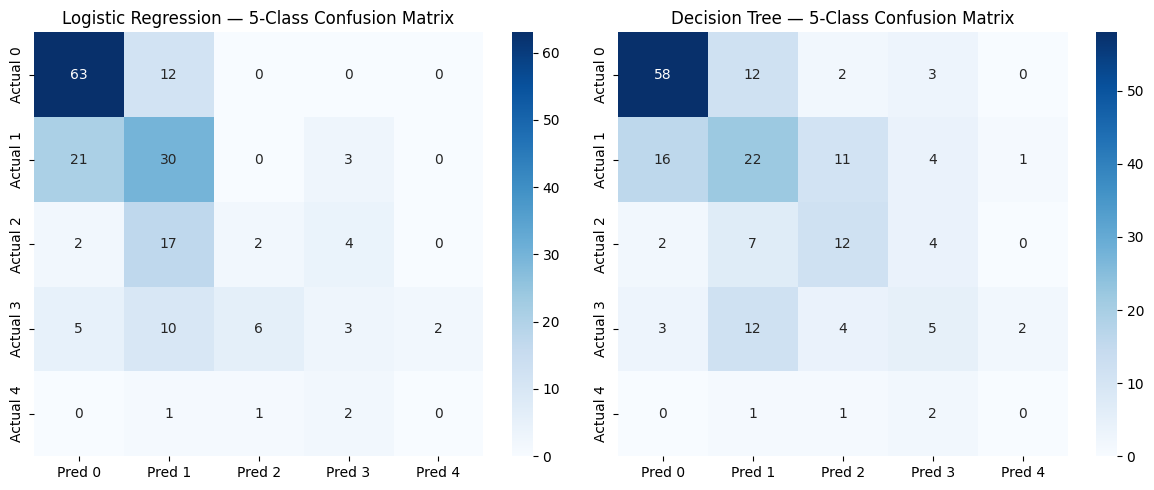

In [21]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes = sorted(y_mc.unique())

for ax, pred, title in zip(axes, [ymc_pred1, ymc_pred2], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test_mc, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[f"Pred {c}" for c in classes],
                yticklabels=[f"Actual {c}" for c in classes])
    ax.set_title(f"{title} — 5-Class Confusion Matrix")

plt.tight_layout()
plt.show()

In [27]:
# simpler version of the above code without heatmaps

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test_mc, ymc_pred1))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test_mc, ymc_pred2))

Logistic Regression Confusion Matrix:
 [[63 12  0  0  0]
 [21 30  0  3  0]
 [ 2 17  2  4  0]
 [ 5 10  6  3  2]
 [ 0  1  1  2  0]]
Decision Tree Confusion Matrix:
 [[58 12  2  3  0]
 [16 22 11  4  1]
 [ 2  7 12  4  0]
 [ 3 12  4  5  2]
 [ 0  1  1  2  0]]


In [32]:
print("Logistic Regression — Per-class Metrics:")
print("Precision:", precision_score(y_test_mc, ymc_pred1, average=None))      
print("Recall:   ", recall_score(y_test_mc, ymc_pred1, average=None))
print("F1-Score: ", f1_score(y_test_mc, ymc_pred1, average=None))


Logistic Regression — Per-class Metrics:
Precision: [0.69230769 0.42857143 0.22222222 0.25       0.        ]
Recall:    [0.84       0.55555556 0.08       0.11538462 0.        ]
F1-Score:  [0.75903614 0.48387097 0.11764706 0.15789474 0.        ]


---
## 8. Classification Report

`classification_report` is sklearn's all-in-one summary — it prints **Precision, Recall, F1-score, and Support** for every class in one table.

```
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       120   ← class 0: no disease
           1       0.72      0.61      0.66        28   ← class 1
           ...

    accuracy                           0.82       200   ← overall accuracy
   macro avg       0.68      0.65      0.66       200   ← unweighted mean across classes
weighted avg       0.81      0.82      0.81       200   ← weighted by support
```

### Reading the Report

| Column | Meaning |
|--------|---------|
| **Precision** | Out of all predicted as this class, how many were correct? |
| **Recall** | Out of all actual samples of this class, how many were found? |
| **F1-score** | Harmonic mean of Precision and Recall for this class |
| **Support** | Number of actual samples of this class in the test set |
| **Accuracy** | Overall fraction of correct predictions (single number) |
| **Macro avg** | Simple mean of all per-class scores (all classes equal weight) |
| **Weighted avg** | Mean weighted by support — reflects real class distribution |

### What to look for

- **Low Recall on a critical class** (e.g. class 1 = disease) → model is missing real cases → increase Recall
- **Low Precision on a class** → model over-predicts that class → many false alarms
- **Large gap between macro and weighted avg** → class imbalance is present
- **Support counts** → small support = unreliable metric for that class

> The Classification Report replaces calling `precision_score`, `recall_score`, and `f1_score` separately — use it as your standard evaluation output.

In [24]:
from sklearn.metrics import classification_report

print("=" * 55)
print("Logistic Regression — Classification Report")
print("=" * 55)
print(classification_report(y_test_mc, ymc_pred1, zero_division=0))

print("=" * 55)
print("Decision Tree — Classification Report")
print("=" * 55)
print(classification_report(y_test_mc, ymc_pred2, zero_division=0))

Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.69      0.84      0.76        75
           1       0.43      0.56      0.48        54
           2       0.22      0.08      0.12        25
           3       0.25      0.12      0.16        26
           4       0.00      0.00      0.00         4

    accuracy                           0.53       184
   macro avg       0.32      0.32      0.30       184
weighted avg       0.47      0.53      0.49       184

Decision Tree — Classification Report
              precision    recall  f1-score   support

           0       0.73      0.77      0.75        75
           1       0.41      0.41      0.41        54
           2       0.40      0.48      0.44        25
           3       0.28      0.19      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.53       184
   macro avg       0.36      0.37      0.36      

---
## 9. Summary — Which Metric to Use?

| Situation | Recommended Metric |
|-----------|-------------------|
| Balanced classes, quick check | **Accuracy** |
| Understand error types in detail | **Confusion Matrix** |
| Cost of false alarm (FP) is high | **Precision** (e.g. spam filter) |
| Cost of missing a positive (FN) is high | **Recall** (e.g. disease detection) |
| Need balance between FP and FN | **F1-Score** |
| Imbalanced data, one number | **Weighted F1** or **Macro F1** |
| Full per-class breakdown | **Classification Report** |

> **Golden rule:** Never rely on accuracy alone. Always check the confusion matrix and use Precision / Recall / F1 depending on what errors matter most in your domain.